<a href="https://colab.research.google.com/github/ZionSants/RedesNeurais/blob/main/NeuralNetworks.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

Epoch 1
-------------------------------
loss: 2.292983  [   64/60000]
loss: 2.280725  [ 6464/60000]
loss: 2.259903  [12864/60000]
loss: 2.264972  [19264/60000]
loss: 2.243521  [25664/60000]
loss: 2.206681  [32064/60000]
loss: 2.228704  [38464/60000]
loss: 2.183781  [44864/60000]
loss: 2.184680  [51264/60000]
loss: 2.156554  [57664/60000]
Test Error: 
 Accuracy: 39.5%, Avg loss: 2.144590 

Epoch 2
-------------------------------
loss: 2.156496  [   64/60000]
loss: 2.141140  [ 6464/60000]
loss: 2.082630  [12864/60000]
loss: 2.109047  [19264/60000]
loss: 2.046310  [25664/60000]
loss: 1.990000  [32064/60000]
loss: 2.027599  [38464/60000]
loss: 1.940943  [44864/60000]
loss: 1.950905  [51264/60000]
loss: 1.880365  [57664/60000]
Test Error: 
 Accuracy: 57.3%, Avg loss: 1.872027 

Epoch 3
-------------------------------
loss: 1.911207  [   64/60000]
loss: 1.874353  [ 6464/60000]
loss: 1.750618  [12864/60000]
loss: 1.797545  [19264/60000]
loss: 1.684266  [25664/60000]
loss: 1.640370  [32064/600

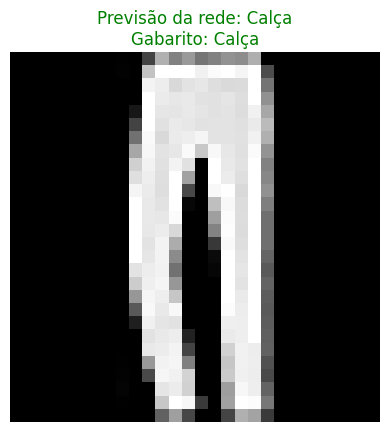

In [ ]:
import torch
from torch import nn
from torch.utils.data import DataLoader
from torchvision import datasets
from torchvision.transforms import v2
import matplotlib.pyplot as plt

training_data = datasets.FashionMNIST(
    root="data",
    train=True,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

test_data = datasets.FashionMNIST(
    root="data",
    train=False,
    download=True,
    transform=v2.Compose([v2.ToImage(), v2.ToDtype(torch.float32, scale=True)])
)

train_dataloader = DataLoader(training_data, batch_size=64)
test_dataloader = DataLoader(test_data, batch_size=64)

class NeuralNetwork(nn.Module):
    def __init__(self):
        super().__init__()
        self.flatten = nn.Flatten()
        self.linear_relu_stack = nn.Sequential(
            nn.Linear(28*28, 512),
            nn.ReLU(),
            nn.Linear(512, 512),
            nn.ReLU(),
            nn.Linear(512, 10),
        )

    def forward(self, x):
        x = self.flatten(x)
        logits = self.linear_relu_stack(x)
        return logits

model = NeuralNetwork()

learning_rate = 1e-3
batch_size = 64


def train_loop(dataloader, model, loss_fn, optimizer):
    size = len(dataloader.dataset)
    # Set the model to training mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.train()
    for batch, (X, y) in enumerate(dataloader):
        # Compute prediction and loss
        pred = model(X)
        loss = loss_fn(pred, y)

        # Backpropagation
        loss.backward()
        optimizer.step()
        optimizer.zero_grad()

        if batch % 100 == 0:
            loss, current = loss.item(), batch * batch_size + len(X)
            print(f"loss: {loss:>7f}  [{current:>5d}/{size:>5d}]")


def test_loop(dataloader, model, loss_fn):
    # Set the model to evaluation mode - important for batch normalization and dropout layers
    # Unnecessary in this situation but added for best practices
    model.eval()
    size = len(dataloader.dataset)
    num_batches = len(dataloader)
    test_loss, correct = 0, 0

    # Evaluating the model with torch.no_grad() ensures that no gradients are computed during test mode
    # also serves to reduce unnecessary gradient computations and memory usage for tensors with requires_grad=True
    with torch.no_grad():
        for X, y in dataloader:
            pred = model(X)
            test_loss += loss_fn(pred, y).item()
            correct += (pred.argmax(1) == y).type(torch.float).sum().item()

    test_loss /= num_batches
    correct /= size
    print(f"Test Error: \n Accuracy: {(100*correct):>0.1f}%, Avg loss: {test_loss:>8f} \n")

epochs = 5
loss_fn = nn.CrossEntropyLoss()
optimizer = torch.optim.SGD(model.parameters(), lr=learning_rate)

for t in range(epochs):
    print(f"Epoch {t+1}\n-------------------------------")
    train_loop(train_dataloader, model, loss_fn, optimizer)
    test_loop(test_dataloader, model, loss_fn)
print("Done!")

classes = [
    "Camiseta", "Calça", "Suéter", "Vestido", "Casaco",
    "Sandália", "Camisa", "Tênis", "Bolsa", "Bota"
]

indice = 2  # Mude este valor para testar imagens diferentes
imagem, label_real = test_data[indice][0], test_data[indice][1]

model.eval()
with torch.no_grad():
    pred = model(imagem)
    indice_previsto = pred.argmax(1).item()
    nome_previsto = classes[indice_previsto]
    nome_real = classes[label_real]

draw_image = imagem.squeeze()

# Exibição da imagem
plt.imshow(draw_image, cmap="gray")

# Cor do texto
cor_do_texto = "green" if indice_previsto == label_real else "red"

plt.title(f"Previsão da rede: {nome_previsto}\nGabarito: {nome_real}", color=cor_do_texto)
plt.axis("off")
plt.show()